# Digital Image Representation

### Import Library 
Langkah awal pengolahan citra, yaitu mengimpor tiga library utama: OpenCV (cv2) untuk manipulasi gambar, NumPy (np) untuk operasi numerik, dan Matplotlib (plt) untuk menampilkan hasil secara visual.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

### Membaca dan Menampilkan Citra Asli (RGB)
Tahap pertama dalam pengolahan citra digital adalah membaca file gambar dari direktori dan menampilkannya dalam format warna yang benar.

OpenCV secara default membaca gambar dalam urutan BGR, sedangkan Matplotlib menampilkan gambar dalam urutan RGB.

Maka digunakan fungsi `cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)` untuk mengonversi urutan kanal warna agar hasil visual di Matplotlib sesuai dengan warna asli gambar.

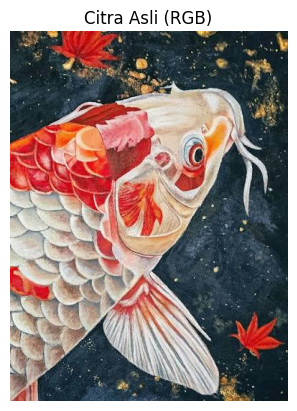

In [15]:
img_bgr = cv2.imread("Input/fish.jpg")
if img_bgr is None:
    raise FileNotFoundError("File citra tidak ditemukan.")

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)
plt.title("RGB")
plt.axis("off")
plt.show()

Jika menampilkan citra asli yang langsung dibaca oleh OpenCV dalam Format BGR

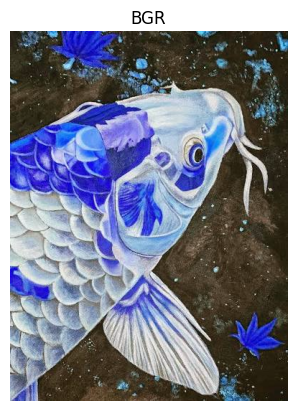

In [38]:
img_bgr = cv2.imread("Input/fish.jpg")
if img_bgr is None:
    raise FileNotFoundError("File citra tidak ditemukan.")

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB) # Untuk konversi dari BGR (default OpenCV) ke RGB (untuk Matplotlib)
plt.imshow(img_bgr) # tes jika ingin tetap menampilkan citra asli dalam format BGR
plt.title("BGR")
plt.axis("off")
plt.show()

### Menampilkan informasi ukuran, kanal, dan tipe data
`img_bgr.shape` menghasilkan tuple (height, width, channels) yang menunjukkan ukuran citra:

- Height → jumlah baris piksel (tinggi gambar).

- Width → jumlah kolom piksel (lebar gambar).

- Channels → jumlah kanal warna (biasanya 3 untuk BGR/RGB).

`img_bgr.dtype` menunjukkan tipe data setiap piksel, biasanya uint8 (nilai 0–255 per kanal).

In [19]:
height, width, channels = img_bgr.shape
dtype = img_bgr.dtype

print(f"Height: {height}")
print(f"Width: {width}")
print(f"Channels: {channels}")
print(f"Dtype: {dtype}")
print(f"Shape: {img_bgr.shape}")

Height: 516
Width: 387
Channels: 3
Dtype: uint8
Shape: (516, 387, 3)


 ### konversi BGR/RGB, grayscale, dan HSV
Konversi ini menampilkan konversi citra dalam 3 ruang warna yang berbeda.

| Representasi Warna | Karakteristik Utama | Fungsi OpenCV | Cara Menampilkan di Matplotlib |
|--------------------|---------------------|---------------|--------------------------------|
| **RGB**            | Tiga kanal warna: Red, Green, Blue. Digunakan untuk menampilkan citra berwarna asli. | `cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)` | `plt.imshow(img_rgb)` |
| **Grayscale**      | Satu kanal intensitas (hitam‑putih). Menyederhanakan citra dengan hanya menampilkan tingkat kecerahan. | `cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)` | `plt.imshow(gray, cmap="gray")` |
| **HSV**            | Memisahkan warna (Hue), kejenuhan (Saturation), dan kecerahan (Value). Cocok untuk analisis warna dan segmentasi. | `cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)` | `plt.imshow(cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB))` |

Prosesnya dimulai dengan konversi dari format BGR (standar OpenCV) ke masing‑masing ruang warna menggunakan `cv2.cvtColor()`. Kemudian, `plt.subplots()` membuat tiga kolom tampilan perbandingan visual.

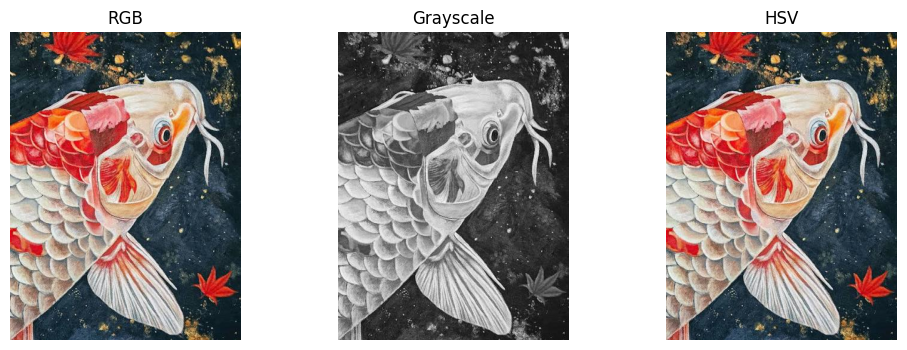

In [20]:
gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
ax[0].set_title("RGB")
ax[1].imshow(gray, cmap="gray")
ax[1].set_title("Grayscale")
ax[2].imshow(cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB))
ax[2].set_title("HSV")
for a in ax: a.axis("off")
plt.show()

Jika citra ditampilkan masih dalam format BGR bawaan OpenCV, warna biru akan tampak dominan karena urutan kanal berbeda dari RGB. Efek ini berpengaruh saat dikonversi ke Grayscale, di mana intensitas biru membuat area tertentu terlihat lebih terang, dan pada HSV perbedaan hue, saturasi, serta value jadi lebih jelas untuk analisis warna.

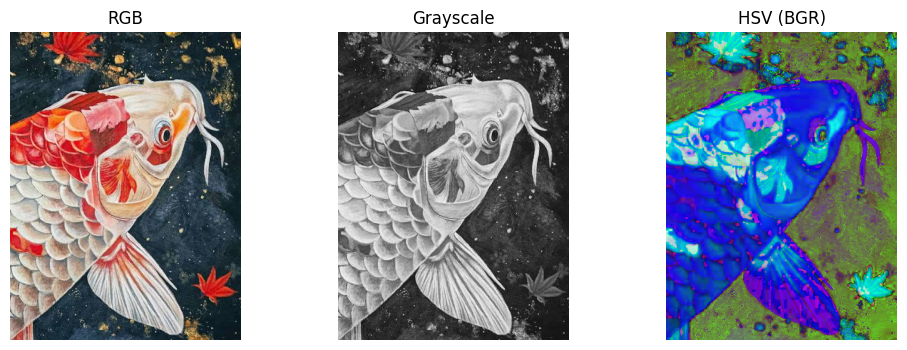

In [57]:
fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(img_rgb)
ax[0].set_title("RGB")
ax[1].imshow(gray, cmap="gray")
ax[1].set_title("Grayscale")
ax[2].imshow(hsv)
ax[2].set_title("HSV (BGR)")
for a in ax: a.axis("off")
plt.show()

### Split kanal RGB/BGR dan visualisasi tiap kanal
Setiap citra berwarna digital disimpan dalam bentuk tiga kanal warna utama: Red, Green, dan Blue (RGB). Masing‑masing kanal menyimpan intensitas cahaya untuk warna tertentu pada setiap piksel:

- Kanal Merah (Red) → berisi nilai intensitas cahaya merah. Semakin tinggi nilainya, semakin kuat kontribusi warna merah pada piksel tersebut.

- Kanal Hijau (Green) → menyimpan intensitas cahaya hijau. Nilai tinggi berarti piksel lebih dominan hijau.

- Kanal Biru (Blue) → menyimpan intensitas cahaya biru. Nilai tinggi menunjukkan piksel lebih kebiruan.

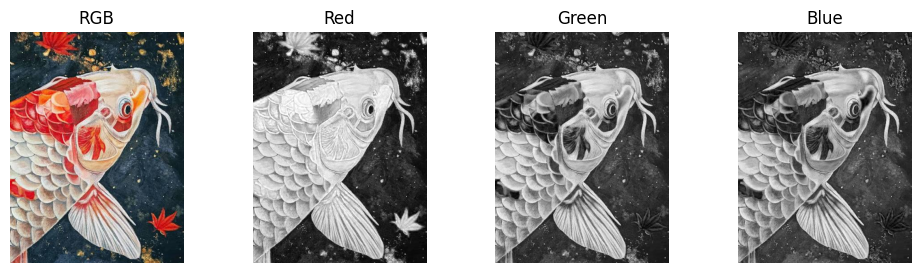

In [21]:
b, g, r = cv2.split(img_bgr)
fig, ax = plt.subplots(1, 4, figsize=(12, 3))
ax[0].imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
ax[0].set_title("RGB")
ax[1].imshow(r, cmap="gray"); ax[1].set_title("Red")
ax[2].imshow(g, cmap="gray"); ax[2].set_title("Green")
ax[3].imshow(b, cmap="gray"); ax[3].set_title("Blue")
for a in ax: a.axis("off")
plt.show()

### Histogram Grayscale
Histogram grayscale tersebut menunjukkan dua puncak intensitas yang menandakan adanya area gelap dan terang yang cukup kontras. Frekuensi tinggi di intensitas rendah berarti banyak piksel berwarna gelap biasanya bagian bayangan atau latar belakang. 

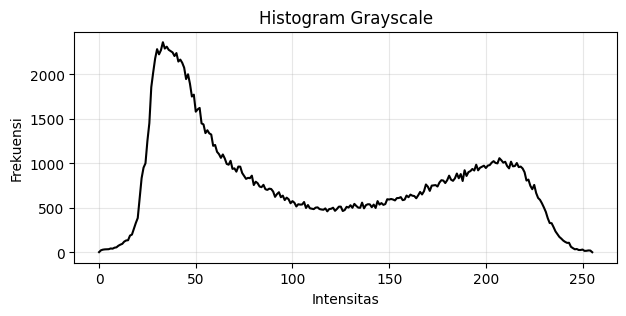

In [22]:
gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
hist = cv2.calcHist([gray], [0], None, [256], [0, 256])

plt.figure(figsize=(7, 3))
plt.plot(hist, color='black')
plt.title("Histogram Grayscale")
plt.xlabel("Intensitas")
plt.ylabel("Frekuensi")
plt.grid(True, alpha=0.3)
plt.show()

### Resize dengan minimal dua metode interpolasi

`INTER_LINEAR` menghitung rata‑rata piksel terdekat sehingga hasilnya halus, sedangkan `INTER_AREA` menggunakan perhitungan area piksel yang lebih akurat untuk mengecilkan gambar.

Secara visual keduanya mirip, tetapi `INTER_AREA` biasanya menghasilkan detail lebih tajam dan minim distorsi saat gambar diperkecil, sedangkan INTER_LINEAR lebih cocok untuk memperbesar ukuran citra.

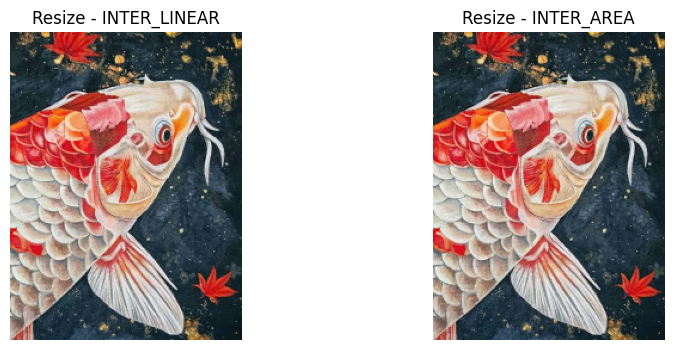

In [23]:
scale = 0.5
resize_linear = cv2.resize(img_bgr, None, fx=scale, fy=scale, interpolation=cv2.INTER_LINEAR)
resize_area = cv2.resize(img_bgr, None, fx=scale, fy=scale, interpolation=cv2.INTER_AREA)

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].imshow(cv2.cvtColor(resize_linear, cv2.COLOR_BGR2RGB))
ax[0].set_title("Resize - INTER_LINEAR")
ax[1].imshow(cv2.cvtColor(resize_area, cv2.COLOR_BGR2RGB))
ax[1].set_title("Resize - INTER_AREA")
for a in ax: a.axis("off")
plt.show()

### Transformasi Geometri
Transformasi rotasi geometris pada citra dilakukan dengan memutar gambar asli sebesar 15° menggunakan matriks rotasi OpenCV untuk mengubah orientasi tanpa mengubah ukuran atau bentuk citra

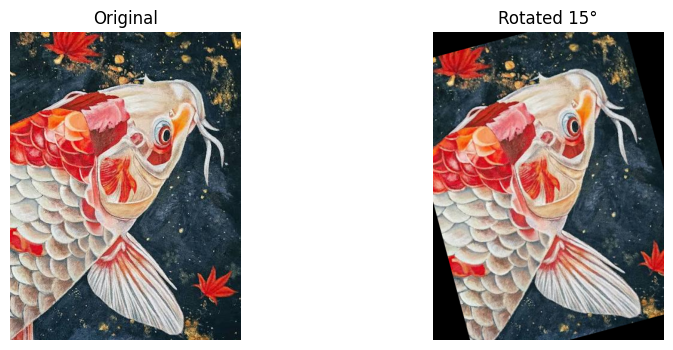

In [24]:
h, w = img_bgr.shape[:2]
center = (w // 2, h // 2)
M = cv2.getRotationMatrix2D(center, 15, 1.0)
rotated = cv2.warpAffine(img_bgr, M, (w, h))

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
ax[0].set_title("Original")
ax[1].imshow(cv2.cvtColor(rotated, cv2.COLOR_BGR2RGB))
ax[1].set_title("Rotated 15°")
for a in ax: a.axis("off")
plt.show()

In [60]:
from pathlib import Path

output_dir = Path("Output")
export_folders = {
    "01_citra_rgb": output_dir / "01_citra_rgb",
    "02_citra_bgr": output_dir / "02_citra_bgr",
    "03_konversi_warna": output_dir / "03_konversi_warna",
    "04_visualisasi_bgr": output_dir / "04_visualisasi_bgr",
    "05_kanal": output_dir / "05_kanal",
    "06_histogram": output_dir / "06_histogram",
    "07_resize": output_dir / "07_resize",
    "08_transformasi_geometri": output_dir / "08_transformasi_geometri",
}

for folder in export_folders.values():
    folder.mkdir(parents=True, exist_ok=True)

cv2.imwrite(str(export_folders["01_citra_rgb"] / "citra_rgb.png"), cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR))
cv2.imwrite(str(export_folders["02_citra_bgr"] / "citra_bgr.png"), img_bgr)

cv2.imwrite(str(export_folders["03_konversi_warna"] / "rgb.png"), img_bgr)
cv2.imwrite(str(export_folders["03_konversi_warna"] / "grayscale.png"), gray)
cv2.imwrite(str(export_folders["03_konversi_warna"] / "hsv.png"), cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR))

cv2.imwrite(str(export_folders["04_visualisasi_bgr"] / "rgb.png"), cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR))
cv2.imwrite(str(export_folders["04_visualisasi_bgr"] / "grayscale.png"), gray)
cv2.imwrite(str(export_folders["04_visualisasi_bgr"] / "hsv.png"), cv2.cvtColor(hsv, cv2.COLOR_RGB2BGR))

cv2.imwrite(str(export_folders["05_kanal"] / "red.png"), r)
cv2.imwrite(str(export_folders["05_kanal"] / "green.png"), g)
cv2.imwrite(str(export_folders["05_kanal"] / "blue.png"), b)

histogram_path = export_folders["06_histogram"] / "histogram_grayscale.png"
plt.figure(figsize=(7, 3))
plt.plot(hist, color="black")
plt.title("Histogram Grayscale")
plt.xlabel("Intensitas")
plt.ylabel("Frekuensi")
plt.grid(True, alpha=0.3)
plt.savefig(histogram_path, bbox_inches="tight", dpi=150)
plt.close()

cv2.imwrite(str(export_folders["07_resize"] / "inter_linear.png"), resize_linear)
cv2.imwrite(str(export_folders["07_resize"] / "inter_area.png"), resize_area)

cv2.imwrite(str(export_folders["08_transformasi_geometri"] / "original.png"), img_bgr)
cv2.imwrite(str(export_folders["08_transformasi_geometri"] / "rotated_15_degree.png"), rotated)

print(f"Semua hasil gambar berhasil diekspor ke: {output_dir.resolve()}")

Semua hasil gambar berhasil diekspor ke: C:\Users\MSI-GAMING\SEMESTER 5\Komputer Vision\Assignment_COMPVIS\Tugas_1\Output


### Interpretasi
Dari percobaan analisis citra yang sudah dilakukan menunjukkan RGB dan HSV berbeda dalam cara merepresentasikan warna, di mana RGB berbasis intensitas cahaya merah, hijau, biru, sedangkan HSV lebih intuitif karena memisahkan hue, saturasi, dan value. OpenCV menggunakan format BGR sehingga gambar bisa tampak salah warna saat ditampilkan di Matplotlib. Histogram grayscale dengan puncak di intensitas rendah menunjukkan banyak area gelap, yang penting untuk memahami kontras citra.

Dalam transformasi ukuran, INTER_LINEAR menghasilkan gambar halus dengan interpolasi bilinear, sedangkan INTER_AREA lebih tepat untuk mengecilkan gambar karena menjaga detail dan mengurangi aliasing. Jika resize dilakukan tanpa menjaga perbandingan panjang‑lebar, bentuk objek bisa berubah dan informasi visual menjadi tidak akurat.